# Data cleaning for E-scooters in Chicago

# Name: Robin Nguyen

**This mini project is part of a bigger project where we analyze the correlations and effects of e-scooters usage with congestion points in Chicago and whether it has a micro or macro effects when other implications are holded. This mini project looks into the E-scooters dataset from Chicago Data Portal and  Explainatory Data Analysis**

### Import libraries


In [ ]:
# Core Libraries
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import os
import glob
import re
import warnings

# Visualization Libraries
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Advanced visualization
from matplotlib.ticker import NullFormatter, FuncFormatter  # Formatting

# Machine Learning Libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils import resample, shuffle
from sklearn.tree import export_text

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## 1. DATA PROCESSING

In [ ]:
# List CSV files
csv_files = [
   "/content/drive/My Drive/data 400/data/uncombined_data/E-Scooter_Trips_2022.csv",
   "/content/drive/My Drive/data 400/data/uncombined_data/E-Scooter_Trips_2023.csv",
   "/content/drive/My Drive/data 400/data/uncombined_data/E-Scooter_Trips_2024.csv",
   "/content/drive/My Drive/data 400/data/uncombined_data/E-Scooter_Trips_2025.csv"
]

# Output file path
output_file = "/content/drive/My Drive/data 400/data/combined_data/2022_2025data.csv"

# Remove the output file if it already exists
if os.path.exists(output_file):
    os.remove(output_file)

# Define chunk size
chunk_size = 100_000

# Process files in chunks
for file in csv_files:
    print(f"Processing file: {file}")
    for chunk in pd.read_csv(file, chunksize=chunk_size, low_memory=False):
        # Append each chunk to the output file
        chunk.to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)

print(f"All files combined and saved to {output_file}")

## 2. Clean Data



In [ ]:
# Import df
file_path = "/content/drive/My Drive/data 400/data/combined_data/2022_2025data.csv"
df= pd.read_csv(file_path)

In [ ]:
# Create a copy
copy_df = df.copy()

In [ ]:
# Convert 'Start Time' and 'End Time' to datetime objects
copy_df['Start Time'] = pd.to_datetime(copy_df['Start Time'])
copy_df['End Time'] = pd.to_datetime(copy_df['End Time'])

# Create new columns for the day of the week
copy_df['Start Day of Week'] = copy_df['Start Time'].dt.day_name()
copy_df['End Day of Week'] = copy_df['End Time'].dt.day_name()

# Create new columns for the date component
copy_df['Start Date'] = copy_df['Start Time'].dt.date
copy_df['End Date'] = copy_df['End Time'].dt.date

# Extract only the time component from the datetime objects
copy_df['Start Time'] = copy_df['Start Time'].dt.time
copy_df['End Time'] = copy_df['End Time'].dt.time

# Preview the changes
display(copy_df[['Start Time', 'Start Day of Week', 'Start Date', 'End Time', 'End Day of Week', 'End Date']].head())

,Start Time,Start Day of Week,Start Date,End Time,End Day of Week,End Date
0,09:00:00,Tuesday,2022-05-10,09:00:00,Tuesday,2022-05-10
1,09:00:00,Tuesday,2022-05-10,09:00:00,Tuesday,2022-05-10
2,09:00:00,Tuesday,2022-05-10,09:00:00,Tuesday,2022-05-10
3,09:00:00,Tuesday,2022-05-10,10:00:00,Tuesday,2022-05-10
4,10:00:00,Tuesday,2022-05-10,10:00:00,Tuesday,2022-05-10


In [ ]:
# View columns
copy_df.columns

Index(['Trip ID', 'Start Time', 'End Time', 'Trip Distance', 'Trip Duration',
       'Vendor', 'Start Community Area Number', 'End Community Area Number',
       'Start Community Area Name', 'End Community Area Name',
       'Start Centroid Latitude', 'Start Centroid Longitude',
       'Start Centroid Location', 'End Centroid Latitude',
       'End Centroid Longitude', 'End Centroid Location', 'Start Day of Week',
       'End Day of Week', 'Start Date', 'End Date'],
      dtype='object')

In [ ]:
# Drop unnecessary columns
copy_df = copy_df.drop(columns=['Start Centroid Latitude', 'Start Centroid Longitude', 'End Centroid Latitude', 'End Centroid Longitude'])

In [ ]:
# Get unique Start Community Area Names
start_areas = copy_df['Start Community Area Name'].dropna().unique()
start_areas.sort()
print(f"Unique Start Community Areas ({len(start_areas)}):")
print(start_areas)

print("-" * 50)

# Get unique End Community Area Names
end_areas = copy_df['End Community Area Name'].dropna().unique()
end_areas.sort()
print(f"Unique End Community Areas ({len(end_areas)}):")
print(end_areas)

Unique Start Community Areas (77):
['Albany Park' 'Archer Heights' 'Armour Square' 'Ashburn' 'Auburn Gresham'
 'Austin' 'Avalon Park' 'Avondale' 'Belmont Cragin' 'Beverly' 'Bridgeport'
 'Brighton Park' 'Burnside' 'Calumet Heights' 'Chatham' 'Chicago Lawn'
 'Clearing' 'Douglas' 'Dunning' 'East Garfield Park' 'East Side'
 'Edgewater' 'Edison Park' 'Englewood' 'Forest Glen' 'Fuller Park'
 'Gage Park' 'Garfield Ridge' 'Grand Boulevard' 'Greater Grand Crossing'
 'Hegewisch' 'Hermosa' 'Humboldt Park' 'Hyde Park' 'Irving Park'
 'Jefferson Park' 'Kenwood' 'Lake View' 'Lincoln Park' 'Lincoln Square'
 'Logan Square' 'Loop' 'Lower West Side' 'Mckinley Park' 'Montclare'
 'Morgan Park' 'Mount Greenwood' 'Near North Side' 'Near South Side'
 'Near West Side' 'New City' 'North Center' 'North Lawndale' 'North Park'
 'Norwood Park' 'Oakland' 'Ohare' 'Portage Park' 'Pullman' 'Riverdale'
 'Rogers Park' 'Roseland' 'South Chicago' 'South Deering' 'South Lawndale'
 'South Shore' 'Uptown' 'Washington Heights'

In [ ]:
# Standard Chicago Community Area codes (1-77)
chicago_community_areas = {
    'Rogers Park': 1, 'West Ridge': 2, 'Uptown': 3, 'Lincoln Square': 4,
    'North Center': 5, 'Lake View': 6, 'Lincoln Park': 7, 'Near North Side': 8,
    'Edison Park': 9, 'Norwood Park': 10, 'Jefferson Park': 11, 'Forest Glen': 12,
    'North Park': 13, 'Albany Park': 14, 'Portage Park': 15, 'Irving Park': 16,
    'Dunning': 17, 'Montclare': 18, 'Belmont Cragin': 19, 'Hermosa': 20,
    'Avondale': 21, 'Logan Square': 22, 'Humboldt Park': 23, 'West Town': 24,
    'Austin': 25, 'West Garfield Park': 26, 'East Garfield Park': 27, 'Near West Side': 28,
    'North Lawndale': 29, 'South Lawndale': 30, 'Lower West Side': 31, 'Loop': 32,
    'Near South Side': 33, 'Armour Square': 34, 'Douglas': 35, 'Oakland': 36,
    'Fuller Park': 37, 'Grand Boulevard': 38, 'Kenwood': 39, 'Washington Park': 40,
    'Hyde Park': 41, 'Woodlawn': 42, 'South Shore': 43, 'Chatham': 44,
    'Avalon Park': 45, 'South Chicago': 46, 'Burnside': 47, 'Calumet Heights': 48,
    'Roseland': 49, 'Pullman': 50, 'South Deering': 51, 'East Side': 52,
    'West Pullman': 53, 'Riverdale': 54, 'Hegewisch': 55, 'Garfield Ridge': 56,
    'Archer Heights': 57, 'Brighton Park': 58, 'Mckinley Park': 59, 'Bridgeport': 60,
    'New City': 61, 'West Elsdon': 62, 'Gage Park': 63, 'Clearing': 64,
    'West Lawn': 65, 'Chicago Lawn': 66, 'West Englewood': 67, 'Englewood': 68,
    'Greater Grand Crossing': 69, 'Ashburn': 70, 'Auburn Gresham': 71, 'Beverly': 72,
    'Washington Heights': 73, 'Mount Greenwood': 74, 'Morgan Park': 75, 'Ohare': 76,
    'Edgewater': 77
}

# Map the names to their area codes
copy_df['Mapped Start Area Code'] = copy_df['Start Community Area Name'].map(chicago_community_areas)
copy_df['Mapped End Area Code'] = copy_df['End Community Area Name'].map(chicago_community_areas)

# Display the results to compare with the existing Number columns
display(copy_df[['Start Community Area Name', 'Mapped Start Area Code', 'Start Community Area Number']].dropna().head())

,Start Community Area Name,Mapped Start Area Code,Start Community Area Number
0,Loop,32.0,32.0
1,Loop,32.0,32.0
2,Loop,32.0,32.0
3,Loop,32.0,32.0
4,Loop,32.0,32.0


In [ ]:
# View df
copy_df.head(5)

,Trip ID,Start Time,End Time,Trip Distance,Trip Duration,Vendor,Start Community Area Number,End Community Area Number,Start Community Area Name,End Community Area Name,Start Centroid Location,End Centroid Location,Start Day of Week,End Day of Week,Start Date,End Date,Mapped Start Area Code,Mapped End Area Code
0,173d3183-1009-7302-173d-318310097302,09:00:00,09:00:00,193,13,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0
1,173d3204-d8be-984c-173d-3204d8be984c,09:00:00,09:00:00,104,43,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0
2,173d326e-fe57-a9de-173d-326efe57a9de,09:00:00,09:00:00,156,36,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0
3,173d39b4-a033-a160-173d-39b4a033a160,09:00:00,10:00:00,"8,168","2,345",Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0
4,173d3deb-46d8-d67a-173d-3deb46d8d67a,10:00:00,10:00:00,51,42,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0


In [ ]:
# View df
copy_df.tail(5)

,Trip ID,Start Time,End Time,Trip Distance,Trip Duration,Vendor,Start Community Area Number,End Community Area Number,Start Community Area Name,End Community Area Name,Start Centroid Location,End Centroid Location,Start Day of Week,End Day of Week,Start Date,End Date,Mapped Start Area Code,Mapped End Area Code
12805611,1370b01a-a0ee-4c5f-bdf3-395ea1d94c20,15:00:00,15:00:00,846,215,Lime,11.0,11.0,Jefferson Park,Jefferson Park,POINT (-87.77116691801392 41.97882998234248),POINT (-87.77116691801392 41.97882998234248),Wednesday,Wednesday,2025-06-18,2025-06-18,11.0,11.0
12805612,60deec48-34c3-4474-bc17-fb3d249c1b63,15:00:00,15:00:00,550,120,Lime,7.0,7.0,Lincoln Park,Lincoln Park,POINT (-87.64948972103552 41.922686117885036),POINT (-87.64948972103552 41.922686117885036),Wednesday,Wednesday,2025-06-18,2025-06-18,7.0,7.0
12805613,0fbc5ca9-3e78-401d-b971-81b3f1d99c69,15:00:00,15:00:00,601,212,Lime,3.0,3.0,Uptown,Uptown,POINT (-87.65587931915151 41.965812077713224),POINT (-87.65587931915151 41.965812077713224),Wednesday,Wednesday,2025-06-18,2025-06-18,3.0,3.0
12805614,31abf3a1-285b-41c2-bfb3-b9fc5c8e05b0,15:00:00,16:00:00,"1,490",430,Lime,22.0,22.0,Logan Square,Logan Square,POINT (-87.69915594576516 41.922759858521665),POINT (-87.69915594576516 41.922759858521665),Wednesday,Wednesday,2025-06-18,2025-06-18,22.0,22.0
12805615,47358f77-b897-4603-bda9-f457a7d81983,15:00:00,15:00:00,738,219,Lime,46.0,46.0,South Chicago,South Chicago,POINT (-87.55142918511247 41.741242815344805),POINT (-87.55142918511247 41.741242815344805),Wednesday,Wednesday,2025-06-18,2025-06-18,46.0,46.0


In [ ]:
# View shape of df
def check_df(df: object, head: object = 5) -> object:
    print("\nShape")
    print(df.shape)
    print("\nTypes")
    print(df.dtypes)
    print("\nNANs")
    print(df.isnull().sum())
    print("\nInfo")
    print(df.info())

# Check shape, datatypes, and na of df
check_df(copy_df)


Shape
(12805616, 18)

Types
Trip ID                         object
Start Time                      object
End Time                        object
Trip Distance                   object
Trip Duration                   object
Vendor                          object
Start Community Area Number    float64
End Community Area Number      float64
Start Community Area Name       object
End Community Area Name         object
Start Centroid Location         object
End Centroid Location           object
Start Day of Week               object
End Day of Week                 object
Start Date                      object
End Date                        object
Mapped Start Area Code         float64
Mapped End Area Code           float64
dtype: object

NANs
Trip ID                            0
Start Time                         0
End Time                           0
Trip Distance                      0
Trip Duration                      0
Vendor                             0
Start Community Area Number

In [ ]:
# Check the number of duplicated rows
total_duplicates = copy_df.duplicated().sum()

print('Total duplicated rows:', total_duplicates)

Total duplicated rows: 0


/tmp/ipykernel_4294/3618523801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=copy_df, x='Start Day of Week', order=day_order, palette='viridis')


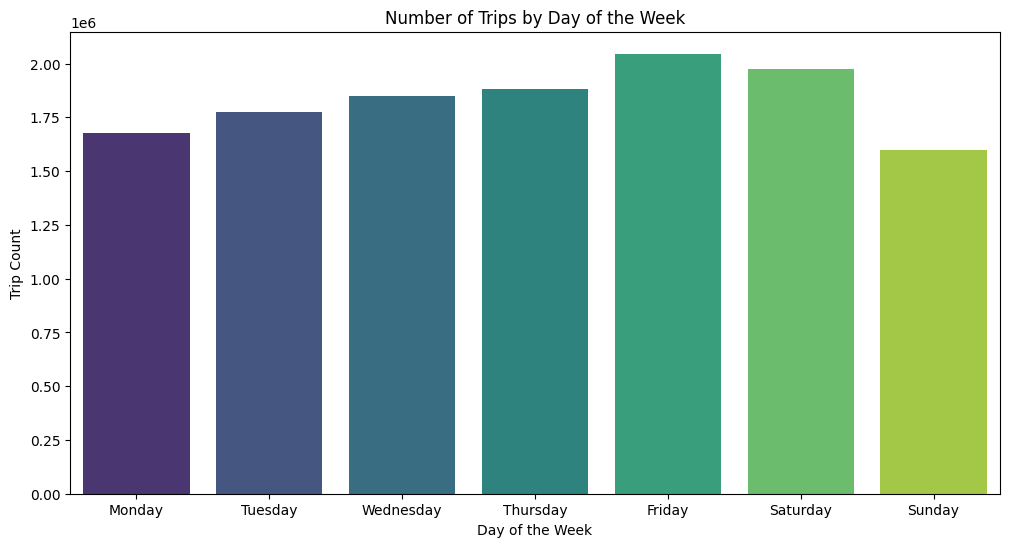

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.countplot(data=copy_df, x='Start Day of Week', order=day_order, palette='viridis')
plt.title('Number of Trips by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Trip Count')
plt.show()

In [ ]:
trip_counts_by_hour = copy_df['Start Time'].apply(lambda x: x.hour).value_counts().sort_values(ascending=False)

# Create a readable DataFrame for the result
trips_summary = trip_counts_by_hour.reset_index()
trips_summary.columns = ['Hour (24h)', 'Trip Count']

print("Time periods with the most trips (from most to least):")
display(trips_summary)

Time periods with the most trips (from most to least):


,Hour (24h),Trip Count
0,17,1187062
1,18,1141422
2,16,1089646
3,19,983718
4,15,947128
5,14,808083
6,20,790743
7,13,745584
8,12,673954
9,21,644161


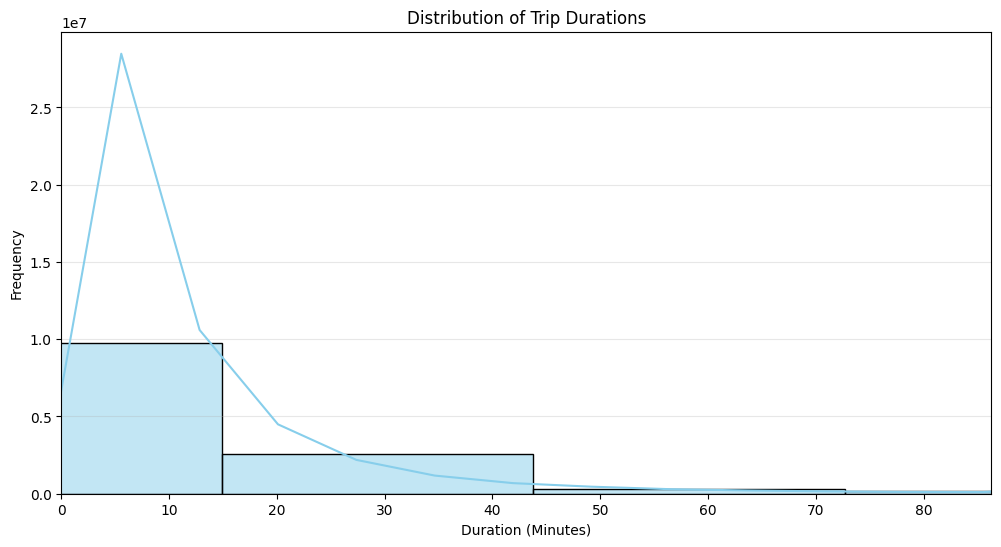

In [ ]:

# Convert Trip Duration to minutes
copy_df['Trip Duration Minutes'] = pd.to_numeric(copy_df['Trip Duration'].astype(str).str.replace(',', ''), errors='coerce') / 60.0

# Plotting the histogram
plt.figure(figsize=(12, 6))
sns.histplot(copy_df['Trip Duration Minutes'].dropna(), bins=50, kde=True, color='skyblue')

plt.title('Distribution of Trip Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

# Setting a limit if there are extreme outliers to make the histogram readable
plt.xlim(0, copy_df['Trip Duration Minutes'].quantile(0.99))

plt.show()

/tmp/ipykernel_4294/563185383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_start_areas.values, y=top_start_areas.index, palette='magma')


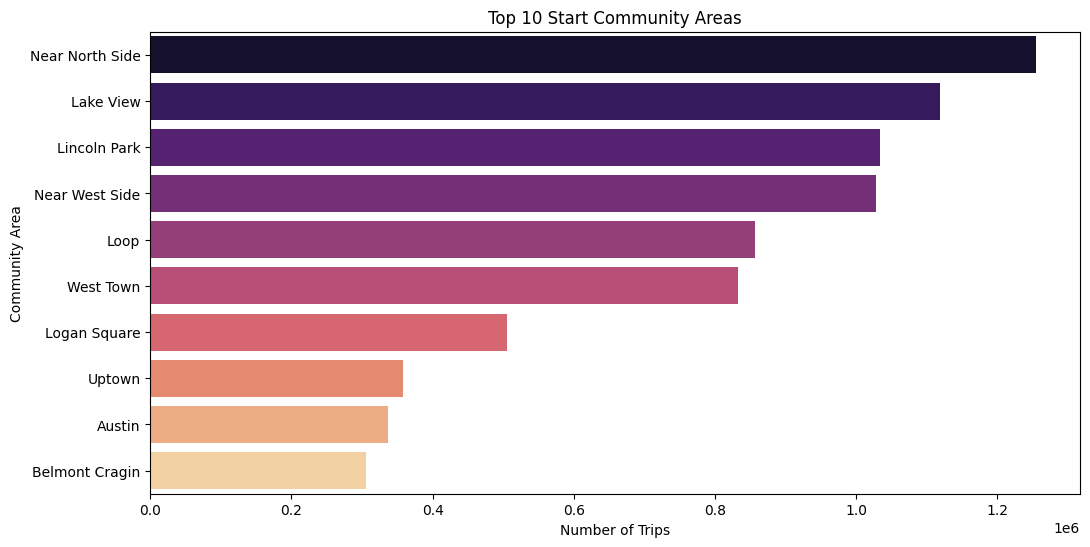

In [ ]:
top_start_areas = copy_df['Start Community Area Name'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_start_areas.values, y=top_start_areas.index, palette='magma')
plt.title('Top 10 Start Community Areas')
plt.xlabel('Number of Trips')
plt.ylabel('Community Area')
plt.show()

In [ ]:
# Export copy_df as cleaned data
output_cleaned_file = "/content/drive/My Drive/data 400/data/combined_data/cleaned_2022_2025data.csv"
copy_df.to_csv(output_cleaned_file, index=False)
print(f"Cleaned data exported to {output_cleaned_file}")

Cleaned data exported to /content/drive/My Drive/data 400/data/combined_data/cleaned_2022_2025data.csv
